# Классификация жестов польского жестового языка (PJM)

## Постановка задачи

Задача: **многоклассовая классификация** жестов по координатам точек руки (hand landmarks),
полученных с помощью Google MediaPipe.

- **Вход**: координаты 21 точки кисти (x, y, z) × 3 фрейма = 63 признака
- **Выход**: класс жеста (буква/знак PJM)
- **Метрики**: Accuracy, F1-macro (macro важен при возможном дисбалансе классов)
- **Целевые значения**: Accuracy ≥ 85%, F1-macro ≥ 0.80

**Актуальность**: автоматическое распознавание жестового языка помогает
слабослышащим людям в коммуникации и может стать основой для систем перевода в реальном времени.
Принцип модели универсален и переносим на другие жестовые языки (РЖЯ, ASL и др.)
при наличии аналогичных данных.

## Импорты и настройка окружения

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import f1_score

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import load_model

from utils import (
    load_data, encode_labels, normalize_landmarks,
    reshape_for_lstm, get_splits,
    build_bilstm,
    plot_training_history, plot_confusion_matrix, print_metrics
)

RANDOM_STATE = 42
DATA_PATH    = 'data/landmarks.csv'

C:\Users\DizzN\AppData\Local\Temp\ipykernel_16764\3754464781.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## 1. Загрузка и разведочный анализ данных (EDA)

In [2]:
df = load_data(DATA_PATH)
print(f"Размер датасета: {df.shape}")
print(f"Столбцы: {df.columns.tolist()[:5]} ...")
df.head()

Размер датасета: (11747, 380)
Столбцы: ['label', 'image_id', '0_point_lm_0_x', '0_point_lm_0_y', '0_point_lm_0_z'] ...


,label,image_id,0_point_lm_0_x,0_point_lm_0_y,0_point_lm_0_z,0_point_lm_1_x,0_point_lm_1_y,0_point_lm_1_z,0_point_lm_2_x,0_point_lm_2_y,...,2_point_vec_15-16_vz,2_point_vec_2-3_vx,2_point_vec_2-3_vy,2_point_vec_2-3_vz,2_point_vec_11-12_vx,2_point_vec_11-12_vy,2_point_vec_11-12_vz,2_point_vec_7-8_vx,2_point_vec_7-8_vy,2_point_vec_7-8_vz
0,a+,1,0.510674,0.58496,-1.844050e-07,0.54497,0.557959,-0.011171,0.567558,0.510413,...,0.005373,-0.003218,-0.043682,0.0005,-0.002581,-0.004002,-0.001635,-0.001923,0.00212,-0.002861
1,a+,2,0.510674,0.58496,-1.844050e-07,0.54497,0.557959,-0.011171,0.567558,0.510413,...,0.005373,-0.003218,-0.043682,0.0005,-0.002581,-0.004002,-0.001635,-0.001923,0.00212,-0.002861
2,a+,3,0.510674,0.58496,-1.844050e-07,0.54497,0.557959,-0.011171,0.567558,0.510413,...,0.005373,-0.003218,-0.043682,0.0005,-0.002581,-0.004002,-0.001635,-0.001923,0.00212,-0.002861
3,a+,4,0.510674,0.58496,-1.844050e-07,0.54497,0.557959,-0.011171,0.567558,0.510413,...,0.005373,-0.003218,-0.043682,0.0005,-0.002581,-0.004002,-0.001635,-0.001923,0.00212,-0.002861
4,a+,5,0.510674,0.58496,-1.844050e-07,0.54497,0.557959,-0.011171,0.567558,0.510413,...,0.005373,-0.003218,-0.043682,0.0005,-0.002581,-0.004002,-0.001635,-0.001923,0.00212,-0.002861


In [3]:
# Пропуски
print("Пропуски:\n", df.isnull().sum().sum())

# Статистика по координатам
df.describe()

Пропуски:
 0


,image_id,0_point_lm_0_x,0_point_lm_0_y,0_point_lm_0_z,0_point_lm_1_x,0_point_lm_1_y,0_point_lm_1_z,0_point_lm_2_x,0_point_lm_2_y,0_point_lm_2_z,...,2_point_vec_15-16_vz,2_point_vec_2-3_vx,2_point_vec_2-3_vy,2_point_vec_2-3_vz,2_point_vec_11-12_vx,2_point_vec_11-12_vy,2_point_vec_11-12_vz,2_point_vec_7-8_vx,2_point_vec_7-8_vy,2_point_vec_7-8_vz
count,11747.000000,11747.000000,11747.000000,1.174700e+04,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,...,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000
mean,220.417043,0.502055,0.520325,8.006674e-08,0.513461,0.495520,-0.020049,0.517699,0.458758,-0.029223,...,0.001665,-0.002249,-0.021895,-0.009168,-0.001976,0.000092,-0.003635,-0.002852,-0.003628,-0.007023
std,143.482530,0.088483,0.137010,2.742795e-07,0.092275,0.118357,0.024003,0.099173,0.091126,0.032583,...,0.009390,0.030306,0.041648,0.009049,0.017665,0.031906,0.007110,0.017595,0.029313,0.006433
min,1.000000,0.058047,0.094569,-1.497130e-06,0.111528,0.166477,-0.198003,0.073690,0.133913,-0.306182,...,-0.046499,-0.168437,-0.235604,-0.109731,-0.125736,-0.130209,-0.063155,-0.120278,-0.129796,-0.059233
25%,95.000000,0.452580,0.437722,-5.559070e-08,0.451556,0.425384,-0.025977,0.445478,0.401850,-0.038210,...,-0.003641,-0.010801,-0.025181,-0.013113,-0.007213,-0.012338,-0.006478,-0.008263,-0.013649,-0.008982
50%,211.000000,0.498456,0.477176,7.432580e-08,0.510925,0.461907,-0.015966,0.513098,0.439146,-0.022904,...,0.002018,0.000523,-0.014660,-0.007976,-0.000695,0.000491,-0.002462,-0.001863,-0.001863,-0.005471
75%,333.000000,0.546688,0.540048,1.824250e-07,0.568174,0.519410,-0.008594,0.585991,0.492636,-0.012857,...,0.005785,0.010449,-0.004046,-0.003544,0.005398,0.010067,0.000749,0.004468,0.009068,-0.003199
max,599.000000,0.920743,1.051685,2.075640e-06,0.942907,0.982492,0.164123,0.940894,0.957477,0.192186,...,0.075123,0.148575,0.148338,0.081505,0.112885,0.168689,0.042171,0.106353,0.147189,0.019634


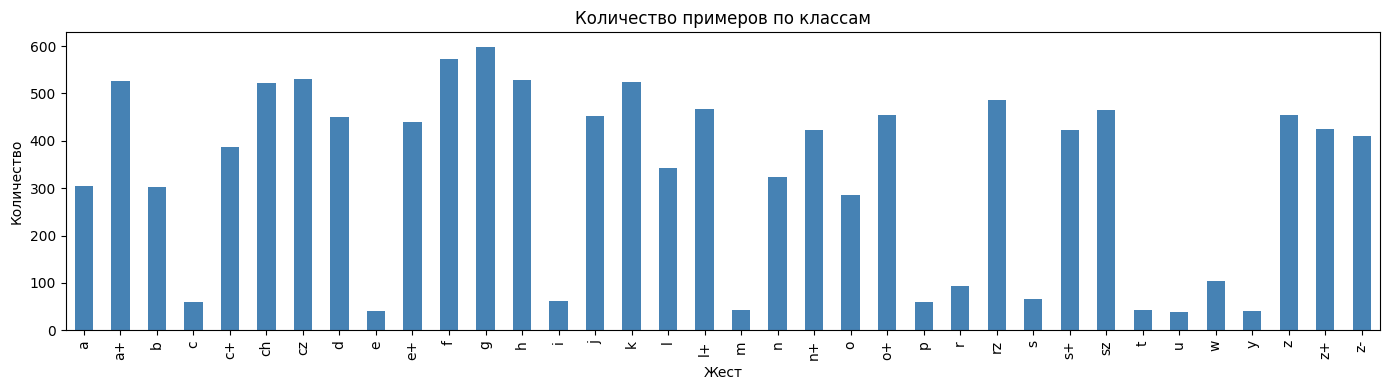

In [4]:
# Распределение классов
plt.figure(figsize=(14, 4))
df['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Количество примеров по классам')
plt.xlabel('Жест')
plt.ylabel('Количество')
plt.tight_layout()
plt.savefig('results/class_distribution.png', dpi=150)
plt.show()

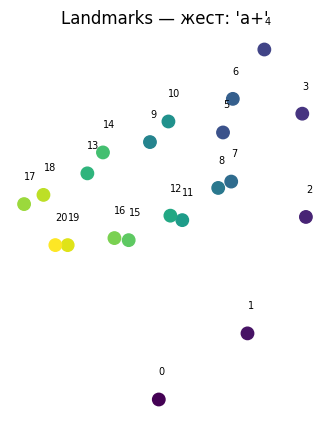

In [6]:
sample = df[df['label'] == df['label'].iloc[0]].iloc[0]

# Берём только столбцы с landmarks для первого фрейма (0_point_lm_*)
lm_cols = [c for c in df.columns if c.startswith('0_point_lm_')]
frame = sample[lm_cols].values.reshape(21, 3)  # (21 точка, xyz)

plt.figure(figsize=(4, 5))
plt.scatter(frame[:, 0], -frame[:, 1], c=range(21), cmap='viridis', s=80)
for i, (x, y, _) in enumerate(frame):
    plt.text(x, -y + 0.01, str(i), fontsize=7)
plt.title(f"Landmarks — жест: '{sample['label']}'")
plt.axis('off')
plt.savefig('results/landmark_example.png', dpi=150)
plt.show()

## 2. Предобработка данных

In [7]:
lm_cols = [c for c in df.columns if '_point_lm_' in c]
X_raw = df[lm_cols].values  # (11747, 189)

y_raw, le = encode_labels(df, 'label')
n_classes   = len(le.classes_)
class_names = le.classes_
print(f"Количество классов: {n_classes}")
print(f"Классы: {class_names}")
print(f"Форма X_raw: {X_raw.shape}")  # должно быть (11747, 189)

Количество классов: 36
Классы: ['a' 'a+' 'b' 'c' 'c+' 'ch' 'cz' 'd' 'e' 'e+' 'f' 'g' 'h' 'i' 'j' 'k' 'l'
 'l+' 'm' 'n' 'n+' 'o' 'o+' 'p' 'r' 'rz' 's' 's+' 'sz' 't' 'u' 'w' 'y' 'z'
 'z+' 'z-']
Форма X_raw: (11747, 189)


In [8]:
# Нормализация + reshape для LSTM и плоский вариант для baseline
X_scaled, scaler = normalize_landmarks(X_raw)

X_lstm = reshape_for_lstm(X_scaled, timesteps=3)   # (samples, 3, 63)
X_flat = X_scaled                                   # (samples, 189) — для RF/SVM

print(f"Форма для LSTM:     {X_lstm.shape}")
print(f"Форма для baseline: {X_flat.shape}")

Форма для LSTM:     (11747, 3, 63)
Форма для baseline: (11747, 189)


In [9]:
# Разбивка train / val / test  (70% / 15% / 15%)
X_train, X_val, X_test, y_train, y_val, y_test = get_splits(X_lstm, y_raw)
X_train_f, _, X_test_f, _, _, _ = get_splits(X_flat, y_raw)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (8222, 3, 63) | Val: (1762, 3, 63) | Test: (1763, 3, 63)


## 3. Baseline-модели (Random Forest, SVM)

Обучаем классические модели на плоском векторе признаков (без учёта временно́й структуры).
Это точка отсчёта для сравнения с BiLSTM.

=== Random Forest ===
              precision    recall  f1-score   support

           a       0.98      1.00      0.99        46
          a+       0.99      0.99      0.99        79
           b       0.98      0.96      0.97        45
           c       0.67      0.44      0.53         9
          c+       1.00      1.00      1.00        58
          ch       1.00      1.00      1.00        78
          cz       0.99      1.00      0.99        80
           d       1.00      1.00      1.00        68
           e       0.67      0.67      0.67         6
          e+       1.00      1.00      1.00        66
           f       1.00      1.00      1.00        86
           g       0.98      1.00      0.99        90
           h       1.00      1.00      1.00        79
           i       1.00      0.89      0.94         9
           j       1.00      1.00      1.00        68
           k       0.98      1.00      0.99        79
           l       0.96      0.98      0.97        52
     

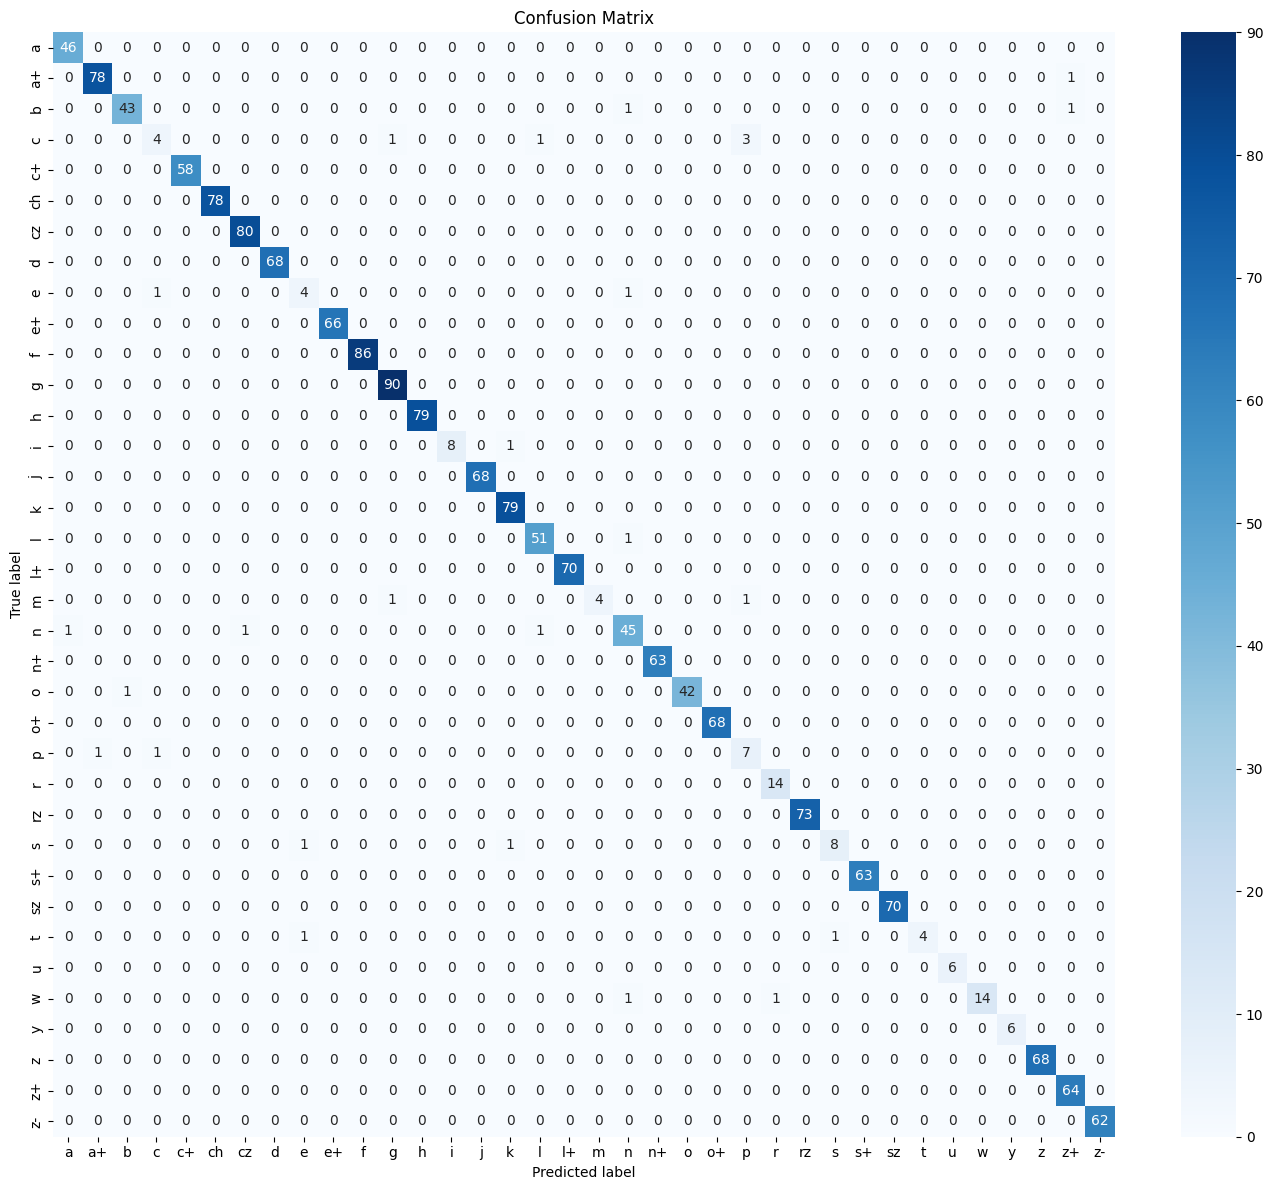

In [10]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_f, y_train)
y_pred_rf = rf.predict(X_test_f)

print("=== Random Forest ===")
f1_rf = print_metrics(y_test, y_pred_rf, class_names)
plot_confusion_matrix(y_test, y_pred_rf, class_names,
                      save_path='results/cm_random_forest.png')

=== Random Forest ===
              precision    recall  f1-score   support

           a       0.98      1.00      0.99        46
          a+       0.99      0.99      0.99        79
           b       0.98      0.96      0.97        45
           c       0.67      0.44      0.53         9
          c+       1.00      1.00      1.00        58
          ch       1.00      1.00      1.00        78
          cz       0.99      1.00      0.99        80
           d       1.00      1.00      1.00        68
           e       0.67      0.67      0.67         6
          e+       1.00      1.00      1.00        66
           f       1.00      1.00      1.00        86
           g       0.98      1.00      0.99        90
           h       1.00      1.00      1.00        79
           i       1.00      0.89      0.94         9
           j       1.00      1.00      1.00        68
           k       0.98      1.00      0.99        79
           l       0.96      0.98      0.97        52
     

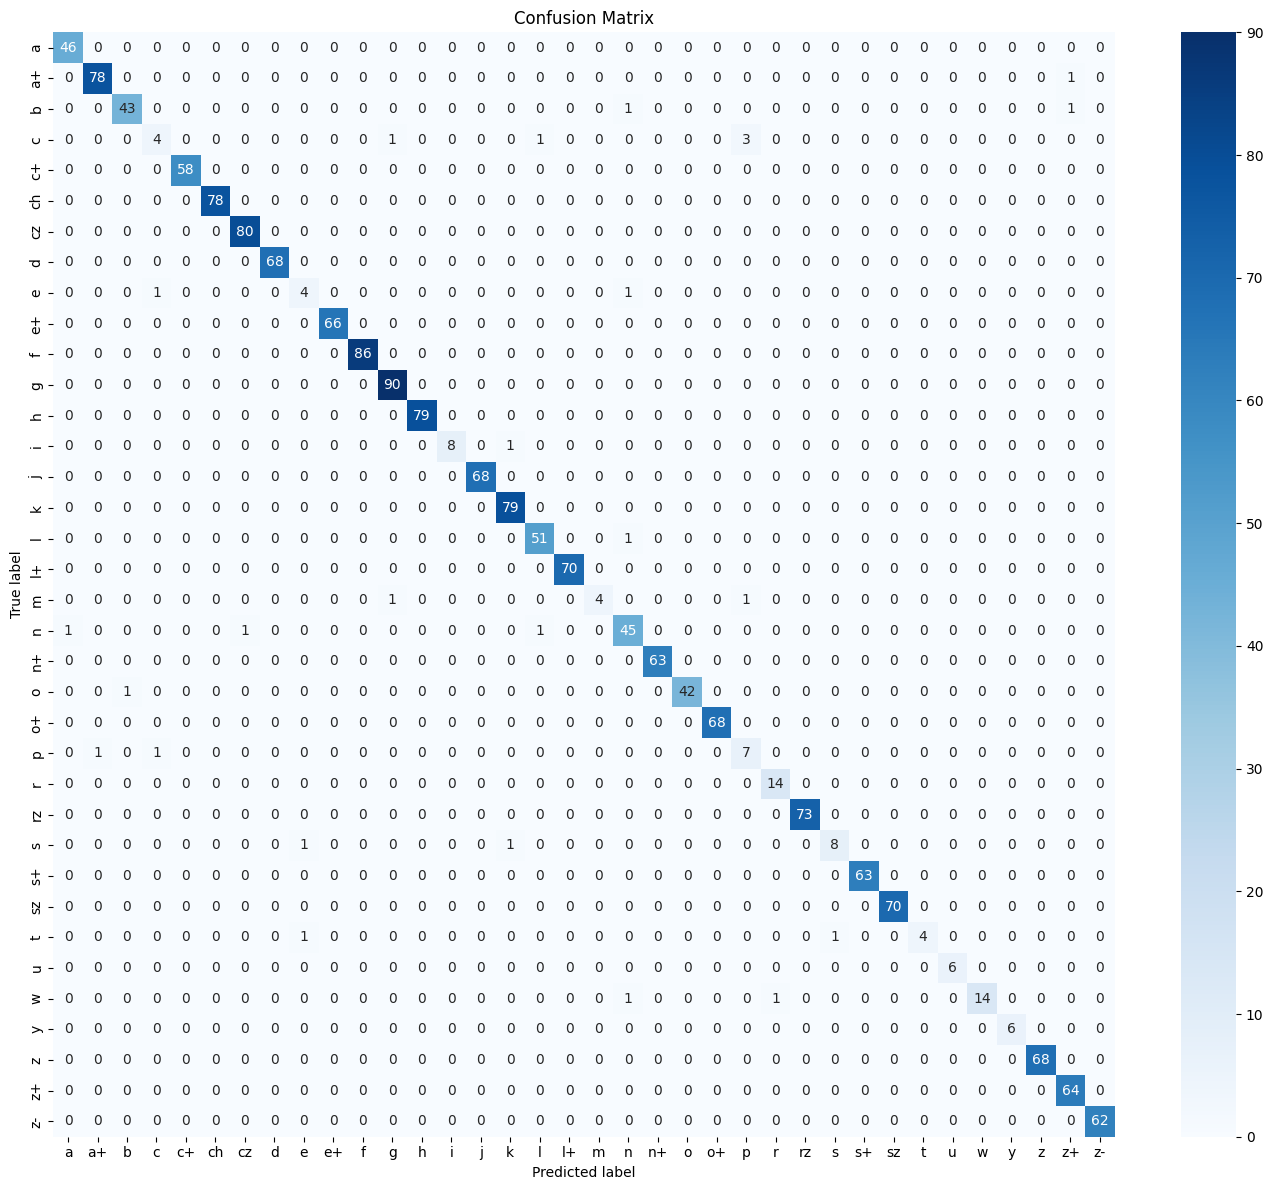

In [11]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_f, y_train)
y_pred_rf = rf.predict(X_test_f)

print("=== Random Forest ===")
f1_rf = print_metrics(y_test, y_pred_rf, class_names)
plot_confusion_matrix(y_test, y_pred_rf, class_names,
                      save_path='results/cm_random_forest.png')

In [12]:
# SVM
svm = SVC(kernel='rbf', C=1.0, random_state=RANDOM_STATE)
svm.fit(X_train_f, y_train)
y_pred_svm = svm.predict(X_test_f)

print("=== SVM ===")
f1_svm = print_metrics(y_test, y_pred_svm, class_names)

=== SVM ===
              precision    recall  f1-score   support

           a       1.00      0.98      0.99        46
          a+       0.84      0.96      0.90        79
           b       0.98      0.98      0.98        45
           c       1.00      0.44      0.62         9
          c+       0.87      0.83      0.85        58
          ch       0.64      0.62      0.63        78
          cz       0.88      0.90      0.89        80
           d       0.94      0.94      0.94        68
           e       0.67      0.67      0.67         6
          e+       0.85      0.79      0.82        66
           f       0.97      0.91      0.94        86
           g       0.95      1.00      0.97        90
           h       0.66      0.82      0.73        79
           i       1.00      0.89      0.94         9
           j       0.95      0.91      0.93        68
           k       0.95      0.99      0.97        79
           l       1.00      0.98      0.99        52
          l+   

## 4. Основная модель — Bidirectional LSTM

Используем временну́ю структуру данных: 3 фрейма как последовательность.
BiLSTM читает последовательность в обоих направлениях, что улучшает качество.

Архитектура: `Input → BiLSTM(64) → Dropout → Dense(128) → Dense(n_classes, softmax)`

In [13]:
input_shape = (X_train.shape[1], X_train.shape[2])  # (3, 63)

model = build_bilstm(
    input_shape=input_shape,
    n_classes=n_classes,
    lstm_units=64,
    dropout_rate=0.3,
    learning_rate=0.001
)
model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirection  (None, 128)               65536     
 al)                                                             
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 128)               16512     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 36)                4644      
                                                                 
Total params: 86692 (338.64 KB)
Trainable params: 86692 (338.64 KB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [14]:
# Callbacks: остановка при отсутствии улучшений + сохранение лучших весов
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('results/best_model.keras', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100


257/257 [==============================] - 3s 5ms/step - loss: 3.1004 - accuracy: 0.1108 - val_loss: 2.4234 - val_accuracy: 0.2724
Epoch 2/100
257/257 [==============================] - 1s 2ms/step - loss: 2.1863 - accuracy: 0.3056 - val_loss: 1.6812 - val_accuracy: 0.5023
Epoch 3/100
257/257 [==============================] - 1s 2ms/step - loss: 1.6534 - accuracy: 0.4538 - val_loss: 1.2151 - val_accuracy: 0.6095
Epoch 4/100
257/257 [==============================] - 1s 2ms/step - loss: 1.3007 - accuracy: 0.5614 - val_loss: 1.0490 - val_accuracy: 0.6351
Epoch 5/100
257/257 [==============================] - 1s 2ms/step - loss: 1.0993 - accuracy: 0.6174 - val_loss: 0.8384 - val_accuracy: 0.7338
Epoch 6/100
257/257 [==============================] - 1s 2ms/step - loss: 0.9955 - accuracy: 0.6513 - val_loss: 0.8061 - val_accuracy: 0.7219
Epoch 7/100
257/257 [==============================] - 1s 2ms/step - loss: 0.8907 - accuracy: 0.6820 - val_loss: 0.7005 - val_accuracy: 0.77

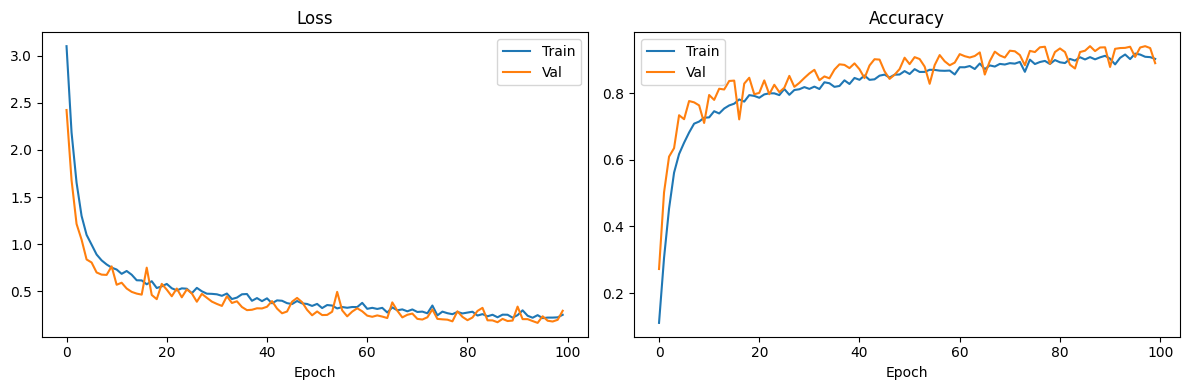

In [15]:
# Графики обучения
plot_training_history(history, save_path='results/training_history.png')

56/56 [==============================] - 0s 1ms/step
=== BiLSTM ===
              precision    recall  f1-score   support

           a       0.94      1.00      0.97        46
          a+       0.74      1.00      0.85        79
           b       0.98      0.98      0.98        45
           c       1.00      0.67      0.80         9
          c+       0.90      0.97      0.93        58
          ch       0.92      0.76      0.83        78
          cz       0.94      0.79      0.86        80
           d       0.89      0.99      0.94        68
           e       0.75      1.00      0.86         6
          e+       0.89      0.52      0.65        66
           f       1.00      0.95      0.98        86
           g       1.00      1.00      1.00        90
           h       0.88      0.81      0.84        79
           i       1.00      0.89      0.94         9
           j       0.78      0.94      0.85        68
           k       1.00      1.00      1.00        79
           l 

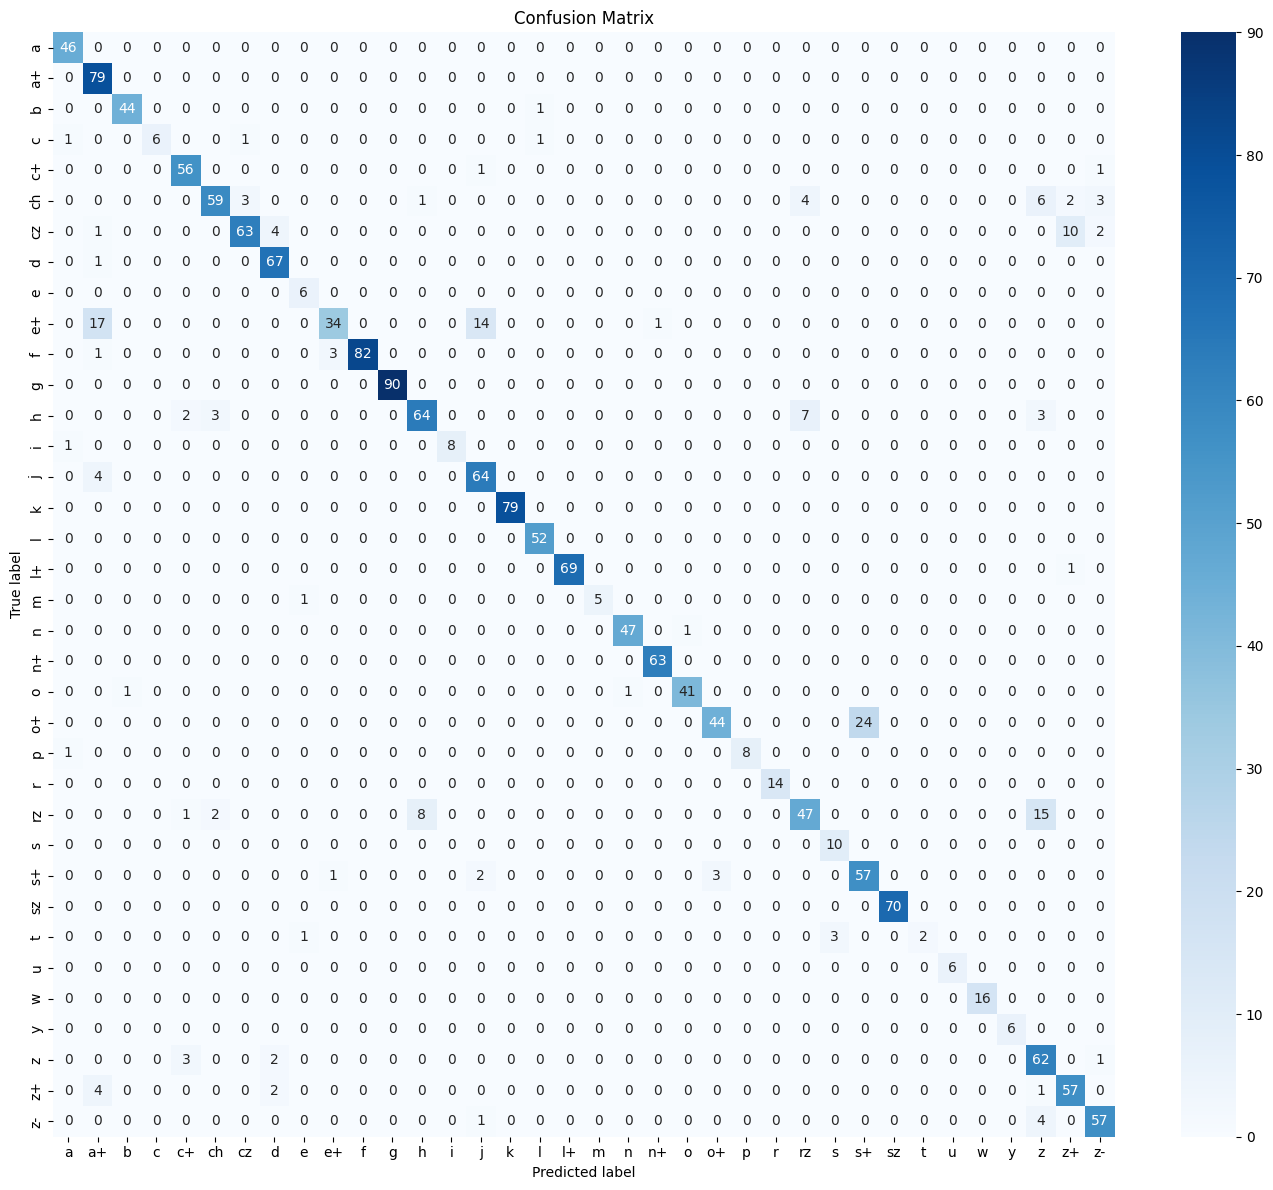

In [16]:
# Оценка на тестовой выборке
y_pred_lstm = model.predict(X_test).argmax(axis=1)

print("=== BiLSTM ===")
f1_lstm = print_metrics(y_test, y_pred_lstm, class_names)
plot_confusion_matrix(y_test, y_pred_lstm, class_names,
                      save_path='results/cm_bilstm.png')

## 5. Сравнение результатов

In [17]:
results = pd.DataFrame([
    {'Модель': 'Random Forest (baseline)', 'F1-macro': round(f1_rf,   4)},
    {'Модель': 'SVM (baseline)',            'F1-macro': round(f1_svm,  4)},
    {'Модель': 'BiLSTM (наша модель)',      'F1-macro': round(f1_lstm, 4)},
])

# Выделяем лучший результат
print(results.to_string(index=False))
results.to_csv('results/metrics_report.csv', index=False)

                  Модель  F1-macro
Random Forest (baseline)    0.9435
          SVM (baseline)    0.8394
    BiLSTM (наша модель)    0.8949


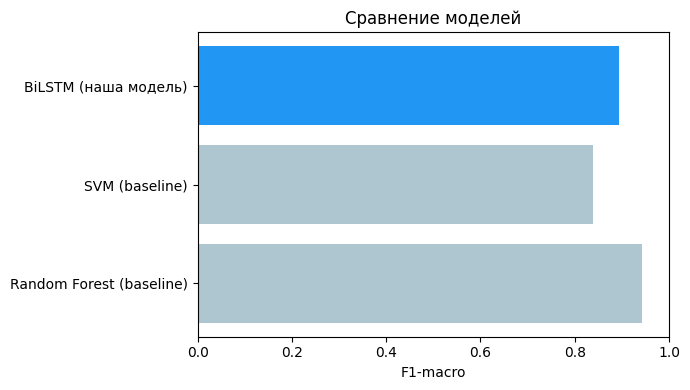

In [18]:
# Визуальное сравнение
plt.figure(figsize=(7, 4))
colors = ['#aec6cf', '#aec6cf', '#2196F3']
plt.barh(results['Модель'], results['F1-macro'], color=colors)
plt.xlim(0, 1.0)
plt.xlabel('F1-macro')
plt.title('Сравнение моделей')
plt.tight_layout()
plt.savefig('results/model_comparison.png', dpi=150)
plt.show()